# NGC 5548 Spectra

Minimal example: resolve NGC 5548 with `SkyCoord.from_name`, query Bandwagon spectra providers, and combine the returned archival spectra metadata.

NGC 5548 is a low-redshift, well-known reverberation-mapped Seyfert 1 AGN. MAST is omitted here to keep the demo focused on ground-based optical spectra.

In [6]:
from pathlib import Path
import sys

from astropy.coordinates import SkyCoord
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

src_root = Path.cwd().resolve().parent / "src"
if src_root.is_dir() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from bandwagon import query_archival_spectra
from bandwagon.spectra import normalize_spectra_tables

try:
    from astroquery.sdss import SDSS
except ImportError:
    SDSS = None

In [7]:
coord = SkyCoord.from_name("NGC 5548")
coord

<SkyCoord (ICRS): (ra, dec) in deg
    (214.49808345, 25.1368342)>

In [8]:
providers = ("desi", "sdss", "gama", "lamost", "6dfgs")
tables = []
failures = {}

for provider in providers:
    try:
        table = query_archival_spectra(
            coord,
            source_id=["NGC 5548"],
            providers=(provider,),
            radius_arcsec=5.0,
        )
    except Exception as exc:
        failures[provider] = f"{type(exc).__name__}: {exc}"
        continue
    tables.append(table)
    print(f"{provider}: {len(table)} spectra rows")

if failures:
    print("\nProviders that could not be queried:")
    for provider, message in failures.items():
        print(f"{provider}: {message}")

sdss: 1 spectra rows
gama: 0 spectra rows
lamost: 0 spectra rows
6dfgs: 0 spectra rows

Providers that could not be queried:
desi: ImportError: Install bandwagon[spectra] to query DESI/SPARCL spectra.


In [9]:
spectra = normalize_spectra_tables(tables)

if len(spectra) > 0:
    spectra.sort(["provider", "match_distance_arcsec"])

display_cols = [
    "source_id",
    "provider",
    "survey",
    "release",
    "instrument",
    "obs_id",
    "target_name",
    "redshift",
    "quality",
    "match_distance_arcsec",
    "access_url",
]
extra_cols = ["sdss_plate", "sdss_mjd", "sdss_fiberid", "sixdfgs_target"]
spectra[[col for col in display_cols + extra_cols if col in spectra.colnames]]

source_id,provider,survey,release,instrument,obs_id,target_name,redshift,quality,match_distance_arcsec,access_url,sdss_plate,sdss_mjd,sdss_fiberid
str8,str4,str4,str4,str4,str13,str19,float64,str1,float64,str1,str4,str5,str2
NGC 5548,sdss,SDSS,dr17,SDSS,2127-53859-85,2394812531219654656,0.01626604,,nan,,2127,53859,85


## Plot Available Spectra

The plotting helper below handles providers that Bandwagon can fetch directly from public archive metadata. SDSS spectra are downloaded with `astroquery.sdss.get_spectra` using plate, MJD, and fiber IDs. 6dFGS target FITS files are opened from WFAU and any spectral extensions after the image extensions are plotted. Providers without implemented download logic are skipped.

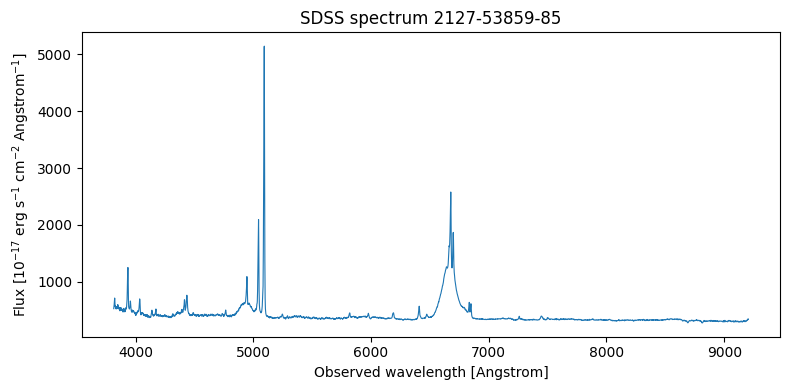

In [10]:
def sixdfgs_fits_url(target_name):
    target_name = str(target_name).strip()
    if not target_name:
        return None
    subdir = target_name[1:3] if target_name[0].lower() in {"g", "c"} else target_name[:2]
    return f"http://www-wfau.roe.ac.uk/6dFGS/dr3_fits/fits/{subdir}/{target_name}.fits"


def sixdfgs_spectral_extensions(hdul):
    spec_exts = []
    for ext, hdu in enumerate(hdul):
        data = hdu.data
        if data is None or getattr(data, "ndim", 0) != 2 or data.shape[0] not in (3, 4):
            continue
        flux = np.asarray(data[0], dtype=float)
        if data.shape[0] == 4:
            wave = np.asarray(data[3], dtype=float)
        else:
            pix = np.arange(flux.size, dtype=float) + 1.0
            wave = hdu.header["CRVAL1"] - (hdu.header["CRPIX1"] - pix) * hdu.header["CDELT1"]
        finite = np.isfinite(wave) & np.isfinite(flux)
        if np.count_nonzero(finite) == 0:
            continue
        spec_exts.append((ext, hdu.name, wave[finite], flux[finite]))
    return spec_exts


def plot_sdss_spectrum(row):
    if SDSS is None:
        print("Install astroquery to fetch and plot SDSS spectra.")
        return
    plate = int(row["sdss_plate"])
    mjd = int(row["sdss_mjd"])
    fiberid = int(row["sdss_fiberid"])
    hdulists = SDSS.get_spectra(plate=plate, mjd=mjd, fiberID=fiberid)
    if not hdulists:
        print(f"No SDSS FITS spectrum returned for {plate}-{mjd}-{fiberid}.")
        return
    data = hdulists[0][1].data
    wave = 10.0 ** np.asarray(data["loglam"], dtype=float)
    flux = np.asarray(data["flux"], dtype=float)
    finite = np.isfinite(wave) & np.isfinite(flux)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(wave[finite], flux[finite], lw=0.8)
    ax.set_xlabel("Observed wavelength [Angstrom]")
    ax.set_ylabel(r"Flux [$10^{-17}$ erg s$^{-1}$ cm$^{-2}$ Angstrom$^{-1}$]")
    ax.set_title(f"SDSS spectrum {plate}-{mjd}-{fiberid}")
    fig.tight_layout()
    plt.show()


def plot_6dfgs_spectrum(row):
    target_name = str(row["target_name"]).strip()
    fits_url = sixdfgs_fits_url(target_name)
    print(f"6dFGS target: {target_name}")
    print(f"FITS URL: {fits_url}")
    with fits.open(fits_url) as hdul:
        spec_exts = sixdfgs_spectral_extensions(hdul)
    if not spec_exts:
        print("No 6dFGS spectral extensions were found for this target.")
        return

    fig, ax = plt.subplots(figsize=(8, 4))
    for ext, name, wave, flux in spec_exts:
        ax.plot(wave, flux, lw=0.8, label=f"ext {ext}: {name}")
    ax.set_xlabel("Wavelength [Angstrom]")
    ax.set_ylabel("6dFGS flux [archive units]")
    ax.set_title(f"6dFGS spectra for {target_name}")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


def plot_spectrum_row(row):
    provider = str(row["provider"]).lower()
    if provider == "sdss":
        plot_sdss_spectrum(row)
    elif provider == "6dfgs":
        plot_6dfgs_spectrum(row)
    else:
        print(f"No plotting fetcher implemented for provider {provider!r}.")


for row in spectra:
    if str(row["provider"]).lower() in {"sdss", "6dfgs"}:
        plot_spectrum_row(row)